In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/cropped_dataset_HE_LAMPHQ.zip"
extract_path = "/content/LAMPHQprocessed_cropped_dataset"

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
print("Extracted files:", os.listdir(extract_path))


Extracted files: ['cropped_dataset_HE_LAMPHQ']


In [ ]:
zip_path = "/content/drive/MyDrive/processed_dataset_CLAHE.zip"
extract_path = "/content/processed_dataset_CLAHE"

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
print("Extracted files:", os.listdir(extract_path))

In [ ]:
zip_path = "/content/drive/MyDrive/combined_dataset.zip"
extract_path = "/content/combined_dataset"

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Verify extraction
print("Extracted files:", os.listdir(extract_path))

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image, ImageOps
from torchvision import transforms

# Function to apply CLAHE, Gamma Correction/Gaussian Blur, and merge them as RGB channels
def preprocess_and_save_images(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    transform_resized = transforms.Resize((224, 224))

    for root, _, files in os.walk(input_dir):
        for file in files:
            if file.endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                file_path = os.path.join(root, file)
                image = Image.open(file_path).convert("L")  # Convert to grayscale
                image_np = np.array(image)  # Convert to NumPy array for OpenCV processing

                # Step 1: CLAHE for high contrast
                clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
                high_contrast = clahe.apply(image_np)

                # Step 2: Gamma Correction or Gaussian Blur for low contrast
                gamma = 2.0  # Adjust gamma for low contrast
                gamma_corrected = np.power(image_np / 255.0, gamma) * 255.0
                low_contrast = gamma_corrected.astype(np.uint8)

                # Alternative: Apply Gaussian blur (uncomment if needed)
                # low_contrast = cv2.GaussianBlur(image_np, (5, 5), 0)

                # Step 3: Original histogram equalized image (mid contrast)
                mid_contrast = cv2.equalizeHist(image_np)

                # Step 4: Merge the three processed images as RGB channels
                combined_image = np.stack([low_contrast, mid_contrast, high_contrast], axis=-1)
                combined_image = Image.fromarray(combined_image)
                combined_image = transform_resized(combined_image)

                # Step 5: Save the processed image with the same folder structure
                rel_path = os.path.relpath(file_path, input_dir)
                save_path = os.path.join(output_dir, rel_path)
                os.makedirs(os.path.dirname(save_path), exist_ok=True)
                combined_image.save(save_path)

# Define input and output directories
input_dir = 'combined_dataset'  # Change this to your actual dataset path
output_dir = 'processed_dataset_CLAHE'

# Run the function
preprocess_and_save_images(input_dir, output_dir)


In [ ]:
from google.colab import drive
import shutil

# Mount your Google Drive
drive.mount('/content/drive')

# Specify the source and destination folders
source_folder = '/content/processed_dataset_CLAHE'  # Replace with the actual folder path
destination_folder = '/content/drive/MyDrive/processed_CLAHE'  # Replace with the desired Drive path

# Copy the folder to your Drive
shutil.copytree(source_folder, destination_folder)

print(f'Folder "{source_folder}" copied to "{destination_folder}" successfully.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder "/content/processed_dataset_CLAHE" copied to "/content/drive/MyDrive/processed_CLAHE" successfully.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import os

# Assumption: The preprocessed dataset already has three contrast-adjusted channels and is stored as 3-channel images.

data_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),  # Mirror augmentation
    transforms.RandomRotation(15),  # Orientation augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Adjust lighting variability
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Use single-channel values if grayscale
])


# Load the preprocessed 3-channel contrast dataset
data_dir = 'processed_dataset_CLAHE'
full_dataset = datasets.ImageFolder(data_dir, transform=data_transform)

# Split dataset into training, validation, and test sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Create DataLoaders with a modest batch size
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader, 'test': test_loader}
dataset_sizes = {'train': train_size, 'val': val_size, 'test': test_size}

# Get class names and count
class_names = full_dataset.classes
num_classes = len(class_names)
print("Number of classes:", num_classes)





Number of classes: 491


In [ ]:
# Model modification with Dropout
class SimpleResNet(nn.Module):
    def __init__(self, num_classes):
        super(SimpleResNet, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

# Initialize model, optimizer, and criterion
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleResNet(num_classes=num_classes).to(device)
# Optimizer with weight decay
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
# Scheduler for learning rate adjustment
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
criterion = nn.CrossEntropyLoss()

In [ ]:

# Training function with early stopping
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, patience=5):
    best_acc = 0.0
    epochs_no_improve = 0
    best_model_wts = model.state_dict()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        scheduler.step()

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    # Calculate accuracy
                    _, preds = torch.max(outputs, 1)
                    running_corrects += torch.sum(preds == labels)
                running_loss += loss.item() * inputs.size(0)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Early stopping check for validation accuracy
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = model.state_dict()
                    epochs_no_improve = 0  # Reset counter if accuracy improves
                    torch.save(model.state_dict(), 'simple_resnet_best.pth')  # Save the best model
                    print("Model improved and saved.")
                else:
                    epochs_no_improve += 1  # Increment counter if no improvement

                if epochs_no_improve >= patience:
                    print("Early stopping triggered.")
                    model.load_state_dict(best_model_wts)
                    return model  # Return the best model early

    # Load the best model weights before returning
    model.load_state_dict(best_model_wts)
    return model

# Train the model with early stopping
model = train_model(model, dataloaders, criterion, optimizer, num_epochs=25, patience=5)


Epoch 1/25
----------


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


train Loss: 5.8619 Acc: 0.0328
val Loss: 5.0788 Acc: 0.0875
Model improved and saved.
Epoch 2/25
----------
train Loss: 4.5844 Acc: 0.1499
val Loss: 3.6827 Acc: 0.2528
Model improved and saved.
Epoch 3/25
----------
train Loss: 3.3711 Acc: 0.3344
val Loss: 2.4949 Acc: 0.4911
Model improved and saved.
Epoch 4/25
----------
train Loss: 2.2708 Acc: 0.5562
val Loss: 1.5163 Acc: 0.7066
Model improved and saved.
Epoch 5/25
----------
train Loss: 1.4453 Acc: 0.7498
val Loss: 0.8240 Acc: 0.8582
Model improved and saved.
Epoch 6/25
----------
train Loss: 0.8941 Acc: 0.8701
val Loss: 0.4875 Acc: 0.9117
Model improved and saved.
Epoch 7/25
----------
train Loss: 0.5954 Acc: 0.9380
val Loss: 0.4069 Acc: 0.9352
Model improved and saved.
Epoch 8/25
----------
train Loss: 0.5402 Acc: 0.9531
val Loss: 0.3497 Acc: 0.9571
Model improved and saved.
Epoch 9/25
----------
train Loss: 0.4965 Acc: 0.9576
val Loss: 0.3172 Acc: 0.9546
Epoch 10/25
----------
train Loss: 0.4751 Acc: 0.9608
val Loss: 0.2968 Acc: 

In [ ]:
# Testing function
def test_model(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    print(f'Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%')

# Test the model
test_model(model, test_loader, criterion)

Test Loss: 0.2052, Test Accuracy: 97.98%


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hoo

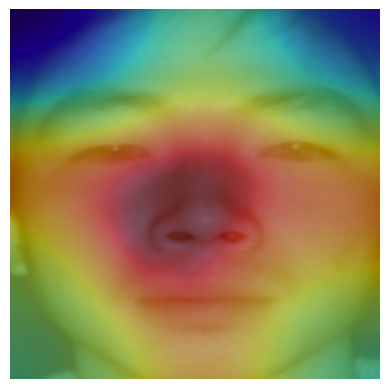

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

# Grad-CAM Class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None

        # Register hooks to capture gradients and features
        self.target_layer.register_forward_hook(self.save_features)
        self.target_layer.register_backward_hook(self.save_gradients)

    def save_features(self, module, input, output):
        self.features = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.to(device)

        # Forward pass
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        # Backward pass for the predicted class
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()

        # Pool the gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        for i in range(self.features.size(1)):
            self.features[0, i, :, :] *= pooled_gradients[i]

        # Generate heatmap
        heatmap = torch.mean(self.features, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy()

# Preprocess a single image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),  # Match training image size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Match training normalization
    ])
    image = Image.open(image_path).convert("RGB")  # Ensure 3-channel image
    input_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return input_tensor, image

# Overlay Grad-CAM heatmap on the original image
def overlay_heatmap(img, heatmap):
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((img.width, img.height), Image.Resampling.LANCZOS)
    heatmap = np.array(heatmap)

    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)  # Overlay heatmap with transparency
    plt.axis('off')
    plt.show()

# Load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleResNet(num_classes=491).to(device)  # Replace 720 with the number of classes in your dataset
model.load_state_dict(torch.load("simple_resnet_best.pth", map_location=device))
model.eval()

target_layer = model.backbone.layer4[-1]  # Instead of layer4[-1]
grad_cam = GradCAM(model, target_layer)

# Generate Grad-CAM heatmap for a single image
image_path = "/content/processed_cropped_dataset/processed_cropped_faces_dataset/00001/001.bmp"  # Replace with the path to your test image
input_tensor, original_image = preprocess_image(image_path)
heatmap = grad_cam(input_tensor)
overlay_heatmap(original_image, heatmap)


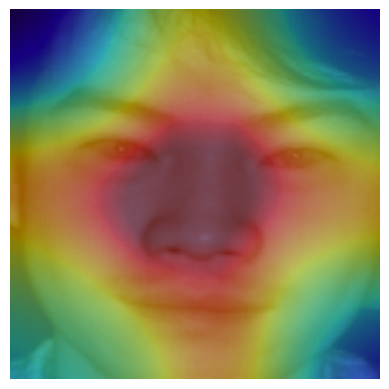

In [ ]:
# Generate Grad-CAM heatmap for a single image
image_path = "/content/processed_cropped_dataset/processed_cropped_faces_dataset/00012/001.bmp"  # Replace with the path to your test image
input_tensor, original_image = preprocess_image(image_path)
heatmap = grad_cam(input_tensor)
overlay_heatmap(original_image, heatmap)

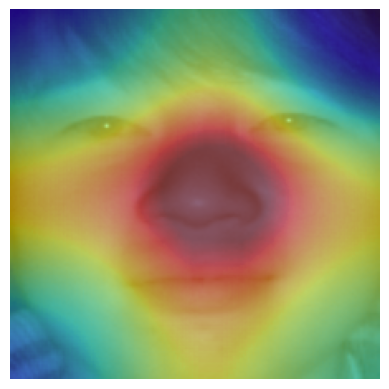

In [ ]:

# Generate Grad-CAM heatmap for a single image
image_path = "/content/processed_cropped_dataset/processed_cropped_faces_dataset/00177/001.bmp"  # Replace with the path to your test image
input_tensor, original_image = preprocess_image(image_path)
heatmap = grad_cam(input_tensor)
overlay_heatmap(original_image, heatmap)

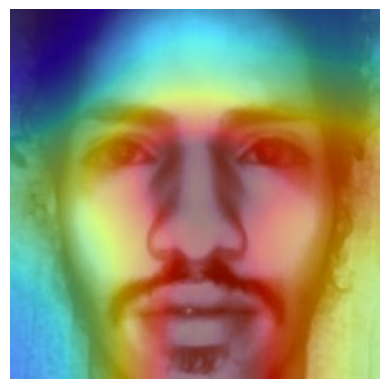

In [ ]:

# Generate Grad-CAM heatmap for a single image
image_path = "/content/LAMPHQprocessed_cropped_dataset/cropped_dataset_HE_LAMPHQ/FP0001/NIR_FP0001_1_DOWN_a.jpg"  # Replace with the path to your test image
input_tensor, original_image = preprocess_image(image_path)
heatmap = grad_cam(input_tensor)
overlay_heatmap(original_image, heatmap)

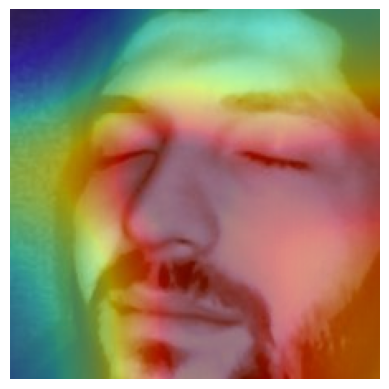

In [ ]:

# Generate Grad-CAM heatmap for a single image
image_path = "/content/LAMPHQprocessed_cropped_dataset/cropped_dataset_HE_LAMPHQ/FP0133/NIR_FP0133_1_RIGHT_d.jpg"  # Replace with the path to your test image
input_tensor, original_image = preprocess_image(image_path)
heatmap = grad_cam(input_tensor)
overlay_heatmap(original_image, heatmap)

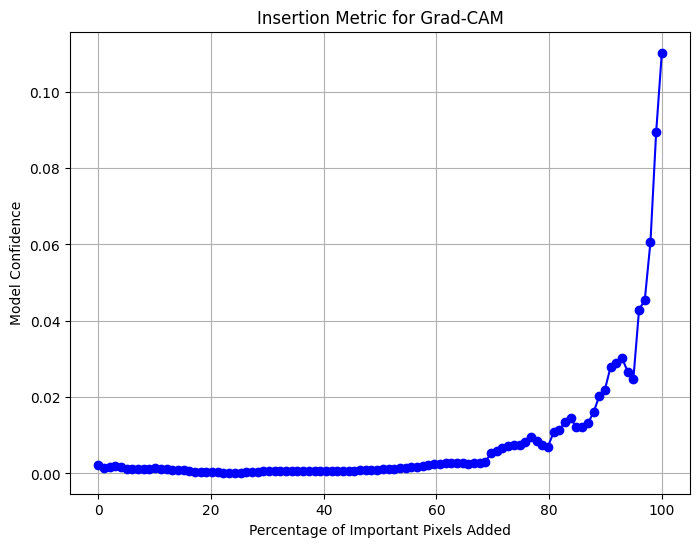

Insertion Score (Higher is Better): 0.0653


<ipython-input-57-2124b33f7cb6>:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_score = np.trapz(normalized_scores, dx=1) / len(normalized_scores)  # Scale correctly


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch.nn.functional as F

# Function to compute Insertion Metric
def apply_insertion_metric(model, input_tensor, gradcam_heatmap, steps=100):
    """
    Evaluates Grad-CAM using the insertion metric.

    Parameters:
    - model: Trained PyTorch model
    - input_tensor: Preprocessed input image tensor
    - gradcam_heatmap: Grad-CAM importance map (same size as image)
    - steps: Number of pixel addition steps

    Returns:
    - insertion_scores: List of confidence scores at each insertion step
    """
    model.eval()
    device = input_tensor.device  # Ensure the correct device

    # Normalize Grad-CAM heatmap
    heatmap = cv2.resize(gradcam_heatmap, (input_tensor.shape[2], input_tensor.shape[3]))
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))

    # Sort pixel indices by importance
    sorted_indices = np.argsort(-heatmap, axis=None)  # Sort in descending importance

    blurred_image = cv2.GaussianBlur(input_tensor.cpu().numpy().squeeze().transpose(1, 2, 0), (5, 5), 0)
    masked_image = blurred_image * 0.1  # Start with 10% visibility instead of black


    insertion_scores = []

    # Get initial confidence score (should be low)
    with torch.no_grad():
        original_pred = model(input_tensor).softmax(dim=1)
        target_class = torch.argmax(original_pred, dim=1).item()
        initial_confidence = original_pred[0, target_class].item()

    total_pixels = len(sorted_indices)

    for step in range(steps):
        # Add top (step/steps)% pixels
        num_pixels_to_add = int((step / steps) * total_pixels)
        indices_to_add = sorted_indices[:num_pixels_to_add]

        # Unravel flat indices into 2D coordinates
        coords = np.unravel_index(indices_to_add, heatmap.shape)

        # Apply pixels gradually
        masked_image[coords] = blurred_image[coords]

        # Convert back to tensor
        modified_tensor = torch.tensor(masked_image.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device)

        # Get new confidence score
        with torch.no_grad():
            new_pred = model(modified_tensor).softmax(dim=1)
            new_confidence = new_pred[0, target_class].item()

        insertion_scores.append(new_confidence)

    return insertion_scores, initial_confidence

# Function to plot Insertion Metric Curve
def plot_insertion_curve(insertion_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(np.linspace(0, 100, len(insertion_scores)), insertion_scores, marker='o', linestyle='-', color='b')
    plt.xlabel('Percentage of Important Pixels Added')
    plt.ylabel('Model Confidence')
    plt.title('Insertion Metric for Grad-CAM')
    plt.grid(True)
    plt.show()

# Compute Insertion Score (Area Under Curve - AUC)
def compute_insertion_score(insertion_scores):
    """
    Computes the AUC for the insertion metric, ensuring correct normalization.
    """
    insertion_scores = np.array(insertion_scores)

    # Normalize scores based on the confidence range (so it doesn't underestimate AUC)
    min_conf = np.min(insertion_scores)
    max_conf = np.max(insertion_scores)

    if max_conf - min_conf == 0:
        return 0  # Avoid division by zero (edge case)

    normalized_scores = (insertion_scores - min_conf) / (max_conf - min_conf)  # Normalize

    auc_score = np.trapz(normalized_scores, dx=1) / len(normalized_scores)  # Scale correctly
    return auc_score



# --- Example Usage ---
# Load Model (already done in your code)
# model = SimpleResNet(num_classes=491).to(device)
# model.load_state_dict(torch.load("simple_resnet_best.pth", map_location=device))
# model.eval()

# Load Image (already done in your code)
image_path = "/content/processed_cropped_dataset/processed_cropped_faces_dataset/00012/001.bmp"
input_tensor, original_image = preprocess_image(image_path)
input_tensor = input_tensor.to(device)  # Ensure input is on same device

# Generate Grad-CAM Heatmap
heatmap = grad_cam(input_tensor)

# Apply Insertion Metric
insertion_scores, initial_confidence = apply_insertion_metric(model, input_tensor, heatmap)

# Plot the Insertion Metric Graph
plot_insertion_curve(insertion_scores)

# Compute Insertion Score
insertion_auc = compute_insertion_score(insertion_scores)
print(f"Insertion Score (Higher is Better): {insertion_auc:.4f}")
